# 2.5 Optimal Trading Strategy

In this notebook, we convert the synthetic alpha signals from Section 2.4 into actual intraday trade schedules.

The previous sections provide:

$$
\text{prices},\quad
\text{fitted impact parameters},\quad
\text{backtest engine},\quad
\text{synthetic alpha signals}.
$$

The output of this notebook is a collection of trade panels

$$
q_{i,d,j},
$$

where:

| Symbol | Meaning |
|---|---|
| $i$ | stock |
| $d$ | trading date |
| $j$ | intraday time bin |
| $q_{i,d,j}>0$ | buy trade |
| $q_{i,d,j}<0$ | sell trade |

The core idea is:

$$
\alpha
\longrightarrow
\text{target impact}
\longrightarrow
\text{target impact state}
\longrightarrow
\text{trades}.
$$

We first construct optimal strategies under the fitted impact models, then compare them to benchmark schedules such as round-trip TWAP. We later extend the same structure to overnight alpha.

---

## 1. Common Inputs and Notation

For each stock-day, we use the following objects.

| Object | Meaning |
|---|---|
| $\alpha_{i,d,j}$ | synthetic alpha level |
| $\alpha'_{i,d,j}$ | alpha time derivative |
| $\beta_i$ | impact decay rate |
| $\Delta t$ | time-bin size |
| $a_i = e^{-\beta_i \Delta t}$ | one-step impact persistence |
| $\hat{\lambda}_i$ | fitted impact scale |
| $\sigma_i$ | stock volatility normalizer |
| $ADV_i$ | average daily volume normalizer |
| $q_{i,d,j}$ | strategy trade in shares |

In discrete time, the alpha derivative is approximated by

$$
\alpha'_{i,d,j}
\approx
\frac{
\alpha_{i,d,j} - \alpha_{i,d,j-1}
}{\Delta t}.
$$

Equivalently, if we define alpha decay as

$$
\text{decay}_{i,d,j}
=
-\alpha'_{i,d,j},
$$

then formulas involving

$$
\alpha - \beta^{-1}\alpha'
$$

can also be written as

$$
\alpha + \beta^{-1}\text{decay}.
$$

This convention must be kept consistent in the code.


---

## 2. OW Optimal Strategy

### 2.1 OW impact dynamics

Under the OW model, the normalized impact state follows

$$
\bar{I}_{i,d,j}^{OW}
=
a_i \bar{I}_{i,d,j-1}^{OW}
+
\sigma_i \frac{q_{i,d,j}}{ADV_i}.
$$

The fitted return impact is then

$$
I_{i,d,j}^{OW}
=
\hat{\lambda}_i
\bar{I}_{i,d,j}^{OW}.
$$

So the fitted model separates the impact into two parts:

| Part | Formula | Meaning |
|---|---|---|
| Normalized state | $\bar{I}^{OW}$ | impact state built from trades |
| Fitted impact | $I^{OW}=\hat{\lambda}\bar{I}^{OW}$ | return impact used in the strategy/backtest |

---

### 2.2 OW target impact

For a deterministic alpha process, the lecture target-impact rule is

$$
I_{i,d,j}^{*,OW}
=
\frac{1}{2}
\left(
\alpha_{i,d,j}
-
\frac{1}{\beta_i}\alpha'_{i,d,j}
\right).
$$

Using the decay convention,

$$
\text{decay}_{i,d,j}=-\alpha'_{i,d,j},
$$

this becomes

$$
I_{i,d,j}^{*,OW}
=
\frac{1}{2}
\left(
\alpha_{i,d,j}
+
\frac{1}{\beta_i}\text{decay}_{i,d,j}
\right).
$$

This target is in **return-impact space**, not share space.

---

### 2.3 Convert OW target impact into target state

Since

$$
I_{i,d,j}^{OW}
=
\hat{\lambda}_i
\bar{I}_{i,d,j}^{OW},
$$

the normalized target impact state is

$$
\bar{I}_{i,d,j}^{*,OW}
=
\frac{
I_{i,d,j}^{*,OW}
}{
\hat{\lambda}_i
}.
$$

---

### 2.4 Recover OW trades

The OW state recurrence is

$$
\bar{I}_{i,d,j}^{*,OW}
=
a_i \bar{I}_{i,d,j-1}^{*,OW}
+
\sigma_i \frac{q_{i,d,j}}{ADV_i}.
$$

Solving for trades gives

$$
q_{i,d,j}^{OW}
=
\frac{ADV_i}{\sigma_i}
\left(
\bar{I}_{i,d,j}^{*,OW}
-
a_i \bar{I}_{i,d,j-1}^{*,OW}
\right).
$$

Equivalently, substituting

$$
\bar{I}^{*,OW}=\frac{I^{*,OW}}{\hat{\lambda}},
$$

we get

$$
q_{i,d,j}^{OW}
=
\frac{ADV_i}{\hat{\lambda}_i\sigma_i}
\left(
I_{i,d,j}^{*,OW}
-
a_i I_{i,d,j-1}^{*,OW}
\right).
$$

---

## 3. AFS Optimal Strategy

### 3.1 AFS impact dynamics

The AFS model introduces a latent volume-space state

$$
J_{i,d,j}
=
a_i J_{i,d,j-1}
+
\sigma_i \frac{q_{i,d,j}}{ADV_i}.
$$

The normalized AFS impact feature is nonlinear:

$$
\bar{I}_{i,d,j}^{AFS}
=
\operatorname{sign}(J_{i,d,j})
|J_{i,d,j}|^c.
$$

For the square-root AFS model,

$$
c=\frac{1}{2},
$$

so

$$
\bar{I}_{i,d,j}^{AFS}
=
\operatorname{sign}(J_{i,d,j})
\sqrt{|J_{i,d,j}|}.
$$

The fitted return impact is

$$
I_{i,d,j}^{AFS}
=
\hat{\lambda}_i
\operatorname{sign}(J_{i,d,j})
|J_{i,d,j}|^c.
$$

---

### 3.2 AFS target impact

For AFS, the lecture target-impact rule is

$$
I_{i,d,j}^{*,AFS}
=
\frac{1}{1+c}
\left(
\alpha_{i,d,j}
-
\frac{1}{\beta_i}\alpha'_{i,d,j}
\right).
$$

For square-root AFS,

$$
c=\frac{1}{2},
$$

therefore

$$
I_{i,d,j}^{*,AFS}
=
\frac{2}{3}
\left(
\alpha_{i,d,j}
-
\frac{1}{\beta_i}\alpha'_{i,d,j}
\right).
$$

Using the decay convention,

$$
\text{decay}_{i,d,j}=-\alpha'_{i,d,j},
$$

this becomes

$$
I_{i,d,j}^{*,AFS}
=
\frac{2}{3}
\left(
\alpha_{i,d,j}
+
\frac{1}{\beta_i}\text{decay}_{i,d,j}
\right).
$$

---

### 3.3 Convert AFS target impact into target $J$ state

The fitted AFS impact is

$$
I_{i,d,j}^{AFS}
=
\hat{\lambda}_i
\operatorname{sign}(J_{i,d,j})
|J_{i,d,j}|^c.
$$

First divide by the fitted impact scale:

$$
\bar{I}_{i,d,j}^{*,AFS}
=
\frac{
I_{i,d,j}^{*,AFS}
}{
\hat{\lambda}_i
}.
$$

Then invert the nonlinear impact map:

$$
J_{i,d,j}^{*}
=
\operatorname{sign}
\left(
\bar{I}_{i,d,j}^{*,AFS}
\right)
\left|
\bar{I}_{i,d,j}^{*,AFS}
\right|^{1/c}.
$$

For square-root AFS, where $c=1/2$,

$$
J_{i,d,j}^{*}
=
\operatorname{sign}
\left(
\bar{I}_{i,d,j}^{*,AFS}
\right)
\left|
\bar{I}_{i,d,j}^{*,AFS}
\right|^{2}.
$$

---

### 3.4 Recover AFS trades

The target $J$ state satisfies

$$
J_{i,d,j}^{*}
=
a_i J_{i,d,j-1}^{*}
+
\sigma_i \frac{q_{i,d,j}}{ADV_i}.
$$

Solving for trades gives

$$
q_{i,d,j}^{AFS}
=
\frac{ADV_i}{\sigma_i}
\left(
J_{i,d,j}^{*}
-
a_i J_{i,d,j-1}^{*}
\right).
$$

So for AFS, the full flow is

$$
\alpha
\longrightarrow
\alpha'
\longrightarrow
I^{*,AFS}
\longrightarrow
\bar{I}^{*,AFS}
\longrightarrow
J^*
\longrightarrow
q^{AFS}.
$$

---

## 4. Comparison of OW and AFS Strategy Construction

| Step | OW | AFS |
|---|---|---|
| Latent state | $\bar{I}^{OW}$ | $J$ |
| State recurrence | $\bar{I}_j=a\bar{I}_{j-1}+\sigma q_j/ADV$ | $J_j=aJ_{j-1}+\sigma q_j/ADV$ |
| Impact map | $I=\hat{\lambda}\bar{I}$ | $I=\hat{\lambda}\operatorname{sign}(J)|J|^c$ |
| Target impact | $\frac{1}{2}(\alpha-\beta^{-1}\alpha')$ | $\frac{1}{1+c}(\alpha-\beta^{-1}\alpha')$ |
| Square-root case | not applicable | $c=1/2$, so coefficient is $2/3$ |
| Inversion | linear | nonlinear |
| Trade recovery | from target $\bar{I}^*$ | from target $J^*$ |

The important difference is that OW is linear all the way from impact to trades. AFS keeps a linear state recurrence, but the map from state to impact is nonlinear. Therefore, AFS requires one extra inversion step:

$$
I^* \rightarrow J^*.
$$

---

## 5. Strategy Objects Built in This Notebook

The notebook constructs trade panels for several strategies.

| Strategy | Description |
|---|---|
| `ow_intraday_only` | OW optimal strategy using intraday synthetic alpha |
| `afs_intraday_only` | AFS optimal strategy using intraday synthetic alpha |
| `round_trip_twap` | benchmark strategy independent of alpha |
| `ow_overnight_only` | OW strategy using overnight alpha only |
| `ow_combined` | OW strategy using intraday plus overnight alpha |

Each strategy produces a trade DataFrame with the same structure:

| Component | Format |
|---|---|
| Index | `(stock, date)` |
| Columns | intraday time bins |
| Values | trades $q_{i,d,j}$ in shares |

This common format allows every strategy to be passed into the same backtest engine.

---

## 6. Implementation Summary

The implementation follows the same structure for each model.

| Step | Operation |
|---|---|
| 1 | Load fitted model parameters |
| 2 | Load synthetic alpha panel |
| 3 | Compute alpha derivative or alpha decay |
| 4 | Compute target impact $I^*$ |
| 5 | Convert target impact into the model-specific target state |
| 6 | Recover trades from the target state recurrence |
| 7 | Normalize or cap trades if required |
| 8 | Backtest the resulting trade panel |

The final output is a dictionary of trade panels:

$$
\{\text{strategy name} \mapsto q_{i,d,j}\}.
$$

This dictionary is then used in the performance-reporting section to compare P&L, transaction costs, drawdowns, and impact dislocations across strategies.

## 1. Imports and paths

This notebook assumes that the helper `.py` files and the saved results from Sections 2.1--2.4 are available in the same folder as this notebook.

In [93]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.backtest_engine import get_best_model_fit_df
from src.optimal_trading_strategies import *

DATA_DIR = Path("data")

DT_SECONDS = 10
TARGET_PARTICIPATION = 0.20
NORMALIZE_ABS_VOLUME = True

TRAIN_MONTH = "201901"
TEST_MONTH = "201902"
N_STOCKS = 20

In [99]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies
import importlib

DATA_DIR = r"data"

DATA_DIR = Path(DATA_DIR) 

importlib.reload(data_prep)
importlib.reload(backtest_engine)
importlib.reload(optimal_trading_strategies)

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *



## 2. Load inputs

In [74]:
# %%
test_px_df = load_panel_csv(
    DATA_DIR / "test_px_201902_20.csv"
)

test_traded_volume_df = load_panel_csv(
    DATA_DIR / "test_traded_volume_201902_20.csv"
)

scaling_df = load_stock_level_csv(
    DATA_DIR / "scaling_201901_20.csv"
)

synthetic_alpha_df = load_panel_csv(
    DATA_DIR / "synthetic_alpha_201902_20.csv"
)

stock_results_df = pd.read_csv(
    DATA_DIR / "impact_model_stock_results_201901_train_201902_test.csv"
)

best_df = pd.read_csv(
    DATA_DIR / "impact_model_best_by_is_201901_train_201902_test.csv"
)

## Create fitted parameter dictionary

In [66]:
# %%
ow_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="ow",
)

afs_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="afs",
)

reduced_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="reduced_form",
)

fit_dfs = {
    "ow": ow_fit_df,
    "afs": afs_fit_df,
    "reduced_form": reduced_fit_df,
}

In [67]:
# %%
for model_name, fit_df in fit_dfs.items():
    print(model_name, fit_df.shape)
    print(fit_df[["lambda_hat", "half_life_seconds", "is_r2", "oos_r2"]].head())

ow (20, 24)
       lambda_hat  half_life_seconds     is_r2    oos_r2
stock                                                   
AAL    262.866026               1800  0.143934  0.199819
AAPL   407.392206               1800  0.231705  0.252164
ABBV   382.822089               1800  0.130716  0.131900
ABT    440.867448               1800  0.171972  0.115936
ADBE   339.189338               1800  0.123732  0.137870
afs (20, 24)
       lambda_hat  half_life_seconds     is_r2    oos_r2
stock                                                   
AAL      0.770608                300  0.151269  0.185629
AAPL     0.828313                300  0.234038  0.227081
ABBV     0.540337                300  0.102414  0.115905
ABT      0.550386                300  0.133748  0.099200
ADBE     0.573366                300  0.130973  0.123505
reduced_form (20, 24)
       lambda_hat  half_life_seconds     is_r2    oos_r2
stock                                                   
AAL     73.752339                600  0.1

### Create alpha dictionary

In [68]:
alpha_dfs = {
    "intraday_only": synthetic_alpha_df,
}

## Construct OW day-only strategy

In [69]:
# %%
(
    ow_day_only_trades_df,
    ow_day_only_target_impact_df,
    ow_day_only_alpha_mu_df,
    ow_day_only_scale_df,
) = make_ow_optimal_trade_df(
    alpha_df=alpha_dfs["intraday_only"],
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["ow"],
    dt_seconds=DT_SECONDS,
    normalize_abs_volume=NORMALIZE_ABS_VOLUME,
    target_participation=TARGET_PARTICIPATION,
)

In [70]:
# %%
print("ow_day_only_trades_df:", ow_day_only_trades_df.shape)
print("ow_day_only_target_impact_df:", ow_day_only_target_impact_df.shape)
print("ow_day_only_alpha_mu_df:", ow_day_only_alpha_mu_df.shape)
print("ow_day_only_scale_df:", ow_day_only_scale_df.shape)

ow_day_only_trades_df: (380, 2341)
ow_day_only_target_impact_df: (380, 2341)
ow_day_only_alpha_mu_df: (380, 2341)
ow_day_only_scale_df: (380, 14)


## Construct AFS day-only strategy

In [75]:
# %%
(
    afs_day_only_trades_df,
    afs_day_only_target_impact_df,
    afs_day_only_alpha_mu_df,
    afs_day_only_scale_df,
) = make_afs_optimal_trade_df(
    alpha_df=alpha_dfs["intraday_only"],
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["afs"],
    dt_seconds=DT_SECONDS,
    c=0.5,
    normalize_abs_volume=NORMALIZE_ABS_VOLUME,
    target_participation=TARGET_PARTICIPATION,
    apply_terminal_condition=True,
)

In [76]:
# %%
print("afs_day_only_trades_df:", afs_day_only_trades_df.shape)
print("afs_day_only_target_impact_df:", afs_day_only_target_impact_df.shape)
print("afs_day_only_alpha_mu_df:", afs_day_only_alpha_mu_df.shape)
print("afs_day_only_scale_df:", afs_day_only_scale_df.shape)

afs_day_only_trades_df: (380, 2341)
afs_day_only_target_impact_df: (380, 2341)
afs_day_only_alpha_mu_df: (380, 2341)
afs_day_only_scale_df: (380, 16)


## Construct reduced-form day-only strategy

In [77]:
# %%
(
    reduced_day_only_trades_df,
    reduced_day_only_target_impact_df,
    reduced_day_only_alpha_mu_df,
    reduced_day_only_local_volume_df,
    reduced_day_only_gamma_prime_df,
    reduced_day_only_scale_df,
) = make_reduced_form_optimal_trade_df(
    alpha_df=alpha_dfs["intraday_only"],
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["reduced_form"],
    dt_seconds=DT_SECONDS,
    normalize_abs_volume=NORMALIZE_ABS_VOLUME,
    target_participation=TARGET_PARTICIPATION,
    use_dynamic_target=True,
    gamma_method="log_backward",
    gamma_clip_multiple=0.5,
)

In [78]:
print("reduced_day_only_trades_df:", reduced_day_only_trades_df.shape)
print("reduced_day_only_target_impact_df:", reduced_day_only_target_impact_df.shape)
print("reduced_day_only_alpha_mu_df:", reduced_day_only_alpha_mu_df.shape)
print("reduced_day_only_local_volume_df:", reduced_day_only_local_volume_df.shape)
print("reduced_day_only_gamma_prime_df:", reduced_day_only_gamma_prime_df.shape)
print("reduced_day_only_scale_df:", reduced_day_only_scale_df.shape)

reduced_day_only_trades_df: (380, 2341)
reduced_day_only_target_impact_df: (380, 2341)
reduced_day_only_alpha_mu_df: (380, 2341)
reduced_day_only_local_volume_df: (380, 2341)
reduced_day_only_gamma_prime_df: (380, 2341)
reduced_day_only_scale_df: (380, 21)


## Store output in dicts

In [79]:
# %%
non_rolling_strategy_outputs = {
    "non_rolling_ow_day_only": {
        "model_type": "ow",
        "alpha_key": "intraday_only",
        "trades": ow_day_only_trades_df,
        "target_impact": ow_day_only_target_impact_df,
        "alpha_mu": ow_day_only_alpha_mu_df,
        "scale": ow_day_only_scale_df,
    },

    "non_rolling_afs_day_only": {
        "model_type": "afs",
        "alpha_key": "intraday_only",
        "trades": afs_day_only_trades_df,
        "target_impact": afs_day_only_target_impact_df,
        "alpha_mu": afs_day_only_alpha_mu_df,
        "scale": afs_day_only_scale_df,
    },

    "non_rolling_reduced_day_only": {
        "model_type": "reduced_form",
        "alpha_key": "intraday_only",
        "trades": reduced_day_only_trades_df,
        "target_impact": reduced_day_only_target_impact_df,
        "alpha_mu": reduced_day_only_alpha_mu_df,
        "local_volume": reduced_day_only_local_volume_df,
        "gamma_prime": reduced_day_only_gamma_prime_df,
        "scale": reduced_day_only_scale_df,
    },
}

In [80]:
# %%
non_rolling_strategy_trade_dfs = {
    strategy_name: strategy_data["trades"]
    for strategy_name, strategy_data in non_rolling_strategy_outputs.items()
}

In [81]:
# %%
for strategy_name, trades_df in non_rolling_strategy_trade_dfs.items():
    print(strategy_name, trades_df.shape)

non_rolling_ow_day_only (380, 2341)
non_rolling_afs_day_only (380, 2341)
non_rolling_reduced_day_only (380, 2341)


## Validation checks

In [82]:
# %%
for strategy_name, strategy_data in non_rolling_strategy_outputs.items():

    trades_df = strategy_data["trades"]
    target_impact_df = strategy_data["target_impact"]
    alpha_mu_df = strategy_data["alpha_mu"]
    scale_df = strategy_data["scale"]

    assert trades_df.shape == test_px_df.shape
    assert target_impact_df.shape == test_px_df.shape
    assert alpha_mu_df.shape == test_px_df.shape

    assert trades_df.index.equals(test_px_df.index)
    assert target_impact_df.index.equals(test_px_df.index)
    assert alpha_mu_df.index.equals(test_px_df.index)

    assert list(trades_df.columns) == list(test_px_df.columns)
    assert list(target_impact_df.columns) == list(test_px_df.columns)
    assert list(alpha_mu_df.columns) == list(test_px_df.columns)

    assert scale_df.shape[0] > 0

print("All strategy output checks passed.")

All strategy output checks passed.


In [83]:
# %%
strategy_volume_check_df = []

for strategy_name, strategy_data in non_rolling_strategy_outputs.items():
    scale_df = strategy_data["scale"].copy()
    scale_df["strategy"] = strategy_name

    strategy_volume_check_df.append(scale_df)

strategy_volume_check_df = pd.concat(strategy_volume_check_df, ignore_index=True)

strategy_volume_check_df.groupby("strategy")[
    ["target_abs_volume", "raw_abs_volume", "actual_abs_volume", "net_traded", "scale_factor"]
].agg(["mean", "median", "std"]).round(4)

target_abs_volume                          \
                                          mean      median         std   
strategy                                                                 
non_rolling_afs_day_only            210496.521  86099.1952  395491.993   
non_rolling_ow_day_only             210496.521  86099.1952  395491.993   
non_rolling_reduced_day_only        210496.521  86099.1952  395491.993   

                             raw_abs_volume                              \
                                       mean        median           std   
strategy                                                                  
non_rolling_afs_day_only       2.761847e+07  1.845678e+07  2.895720e+07   
non_rolling_ow_day_only        9.120921e+07  4.069491e+07  1.454286e+08   
non_rolling_reduced_day_only   1.942843e+07  9.519752e+06  3.075296e+07   

                             actual_abs_volume                          \
                                          mean      median         std   
strategy                                                                 
non_rolling_afs_day_only            210496.521  86099.1952  395491.993   
non_rolling_ow_day_only             210496.521  86099.1952  395491.993   
non_rolling_reduced_day_only        210496.521  86099.1952  395491.993   

                             net_traded                     scale_factor  \
                                   mean   median        std         mean   
strategy                                                                   
non_rolling_afs_day_only       161.5644  66.6937  5421.9772       0.0060   
non_rolling_ow_day_only          7.4712   2.8663   204.7195       0.0021   
non_rolling_reduced_day_only    61.6001  21.9230  1708.7634       0.0095   

                                              
                              median     std  
strategy                                      
non_rolling_afs_day_only      0.0051  0.0036  
non_rolling_ow_day_only       0.0020  0.0005  
non_rolling_reduced_day_only  0.0091  0.0025

## Saving files

In [84]:
# %%
def save_panel_df(df, path):
    """
    Save a stock-date x intraday-time panel.
    """
    df.reset_index().to_csv(path, index=False)


def save_strategy_outputs(strategy_outputs, output_dir):
    """
    Save all strategy outputs using a consistent file naming convention.
    """
    manifest_rows = []
    scale_dfs = []

    for strategy_name, strategy_data in strategy_outputs.items():

        model_type = strategy_data["model_type"]
        alpha_key = strategy_data["alpha_key"]

        trade_file = output_dir / f"strategy_trades_{strategy_name}_201902_20.csv"
        target_file = output_dir / f"strategy_target_impact_{strategy_name}_201902_20.csv"
        alpha_mu_file = output_dir / f"strategy_alpha_mu_{strategy_name}_201902_20.csv"
        scale_file = output_dir / f"strategy_scale_{strategy_name}_201902_20.csv"

        save_panel_df(strategy_data["trades"], trade_file)
        save_panel_df(strategy_data["target_impact"], target_file)
        save_panel_df(strategy_data["alpha_mu"], alpha_mu_file)

        scale_df = strategy_data["scale"].copy()
        scale_df["strategy"] = strategy_name
        scale_df["model_type"] = model_type
        scale_df["alpha_key"] = alpha_key
        scale_df.to_csv(scale_file, index=False)

        scale_dfs.append(scale_df)

        local_volume_file = None
        gamma_prime_file = None

        if "local_volume" in strategy_data:
            local_volume_file = output_dir / f"strategy_local_volume_{strategy_name}_201902_20.csv"
            save_panel_df(strategy_data["local_volume"], local_volume_file)

        if "gamma_prime" in strategy_data:
            gamma_prime_file = output_dir / f"strategy_gamma_prime_{strategy_name}_201902_20.csv"
            save_panel_df(strategy_data["gamma_prime"], gamma_prime_file)

        manifest_rows.append({
            "strategy": strategy_name,
            "model_type": model_type,
            "alpha_key": alpha_key,
            "rolling": False,
            "trade_file": trade_file.name,
            "target_impact_file": target_file.name,
            "alpha_mu_file": alpha_mu_file.name,
            "scale_file": scale_file.name,
            "local_volume_file": None if local_volume_file is None else local_volume_file.name,
            "gamma_prime_file": None if gamma_prime_file is None else gamma_prime_file.name,
            "dt_seconds": DT_SECONDS,
            "target_participation": TARGET_PARTICIPATION,
            "normalize_abs_volume": NORMALIZE_ABS_VOLUME,
        })

    manifest_df = pd.DataFrame(manifest_rows)

    all_scale_df = pd.concat(scale_dfs, ignore_index=True)

    manifest_df.to_csv(
        output_dir / "strategy_manifest_non_rolling_day_only_201902_20.csv",
        index=False,
    )

    all_scale_df.to_csv(
        output_dir / "strategy_scale_non_rolling_day_only_all_201902_20.csv",
        index=False,
    )

    return manifest_df, all_scale_df

In [85]:
# %%
strategy_manifest_df, strategy_scale_all_df = save_strategy_outputs(
    strategy_outputs=non_rolling_strategy_outputs,
    output_dir=DATA_DIR,
)

## Plots

In [105]:
stock = "AAPL"
date = "2019-02-21"

paths, summaries = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={
        "OW optimal": ow_day_only_trades_df,
        "AFS optimal": afs_day_only_trades_df,
        "Reduced-form optimal": reduced_day_only_trades_df,
    },
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
)

summaries

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds
OW optimal,-2000.503115,2539.667123,0.042788,-27.143271,593692.561905,-27.143271,171.293967,101695953.906847,reduced_form,AAPL,2019-02-21,106.653594,2968462.809524,0.000288,600.0
AFS optimal,-3463.786112,3371.691212,0.049662,-385.897564,593692.561905,-385.897564,171.293967,101695953.906847,reduced_form,AAPL,2019-02-21,106.653594,2968462.809524,0.000288,600.0
Reduced-form optimal,-2512.324541,2623.822551,0.026233,20.261165,593692.561905,20.261165,171.293967,101695953.906847,reduced_form,AAPL,2019-02-21,106.653594,2968462.809524,0.000288,600.0


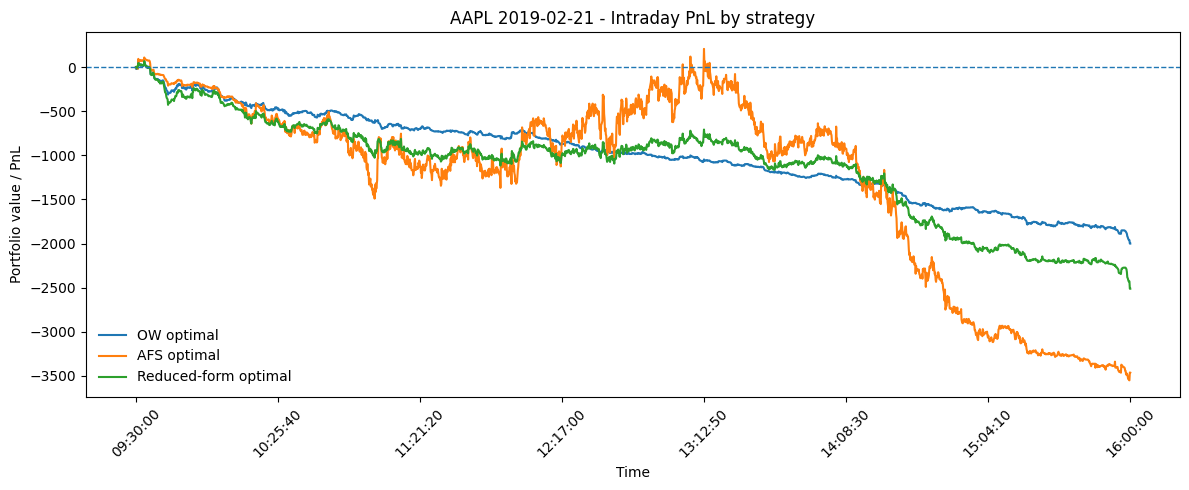

In [106]:
plot_one_stock_day_pnl_comparison(paths, stock, date)

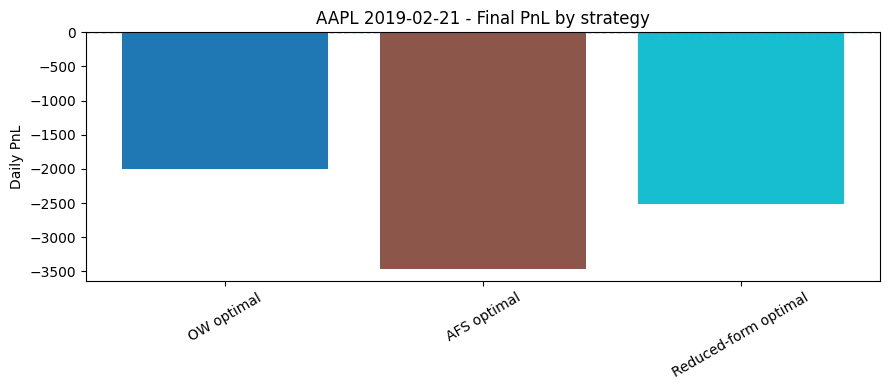

In [107]:
plot_one_stock_day_final_pnl_bar(summaries, stock, date)

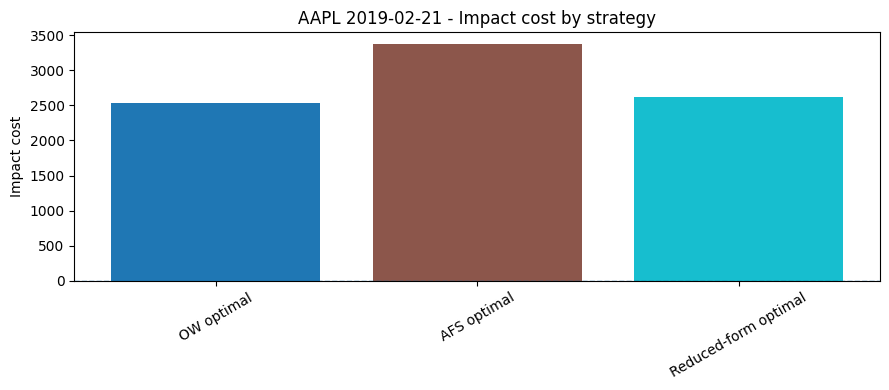

In [108]:
plot_one_stock_day_impact_cost_bar(summaries, stock, date)

In [104]:
stock = "AAPL"
date = "2019-02-21"

ow_row = trades_df.loc[(stock, date)].astype(float)
rf_row = reduced_day_only_trades_df.loc[(stock, date)].astype(float)

print("Same object?", trades_df is reduced_day_only_trades_df)
print("All close?", np.allclose(ow_row.values, rf_row.values))
print("Max abs diff:", np.max(np.abs(ow_row.values - rf_row.values)))
print("OW abs volume:", ow_row.abs().sum())
print("RF abs volume:", rf_row.abs().sum())
print("OW net:", ow_row.sum())
print("RF net:", rf_row.sum())

Same object? True
All close? True
Max abs diff: 0.0
OW abs volume: 593692.561904762
RF abs volume: 593692.561904762
OW net: 20.26116546436174
RF net: 20.26116546436174
